# ⚖️ 06 — Fairness Audit
### Data Flow
```
data/02_test.csv + outputs/best_model.pth → fairness metrics + plots
```


In [1]:

import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.insert(0, '..')
import os, torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference,
    equalized_odds_difference, selection_rate,
    true_positive_rate, false_positive_rate
)
from sklearn.metrics import accuracy_score
from src.model import CreditRiskDNN

os.makedirs('plots', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.1)


## 1. Load Data + Model + Predictions

In [2]:

df_test       = pd.read_csv('../data/02_test.csv')
feature_names = [c for c in df_test.columns if c != 'DEFAULT']
X_test        = df_test[feature_names].values.astype(np.float32)
y_test        = df_test['DEFAULT'].values.astype(int)

model = CreditRiskDNN(n_features=len(feature_names))
model.load_state_dict(torch.load('../outputs/best_model.pth', map_location='cpu'))
model.eval()

with torch.no_grad():
    probs  = torch.sigmoid(model(torch.tensor(X_test))[0]).numpy().flatten()
y_pred = (probs >= 0.4).astype(int)

print(f"Test samples     : {len(y_test):,}")
print(f"Predicted default: {y_pred.sum():,}  ({y_pred.mean():.1%})")


Test samples     : 6,542
Predicted default: 2,982  (45.6%)


## 2. Fairness by Age Group

In [3]:

AGE_IDX    = feature_names.index('AGE')
age_scaled = df_test['AGE'].values
age_groups = np.where(age_scaled < -0.5, 'Young (<30)',
             np.where(age_scaled > 0.8,  'Senior (>50)', 'Middle (30-50)'))

mf_age = MetricFrame(
    metrics={
        'accuracy':            lambda yt,yp: accuracy_score(yt,yp),
        'selection_rate':      selection_rate,
        'true_positive_rate':  true_positive_rate,
        'false_positive_rate': false_positive_rate,
    },
    y_true=y_test, y_pred=y_pred, sensitive_features=age_groups
)

dp_age = demographic_parity_difference(y_test, y_pred, sensitive_features=age_groups)
eo_age = equalized_odds_difference(y_test,    y_pred, sensitive_features=age_groups)

print("Metrics by Age Group:")
print(mf_age.by_group.round(4).to_string())
print(f"\nDemographic Parity Diff : {dp_age:.4f}  (threshold: 0.10)")
print(f"Equalized Odds Diff     : {eo_age:.4f}  (threshold: 0.10)")
print(f"Status: {'⚠️ BIAS DETECTED' if abs(dp_age)>0.1 or abs(eo_age)>0.1 else '✅ Within bounds'}")


Metrics by Age Group:
                     accuracy  selection_rate  true_positive_rate  false_positive_rate
sensitive_feature_0                                                                   
Middle (30-50)         0.7082          0.4384              0.7652               0.3136
Senior (>50)           0.6949          0.4792              0.7725               0.3415
Young (<30)            0.6961          0.4643              0.7873               0.3392

Demographic Parity Diff : 0.0408  (threshold: 0.10)
Equalized Odds Diff     : 0.0280  (threshold: 0.10)
Status: ✅ Within bounds


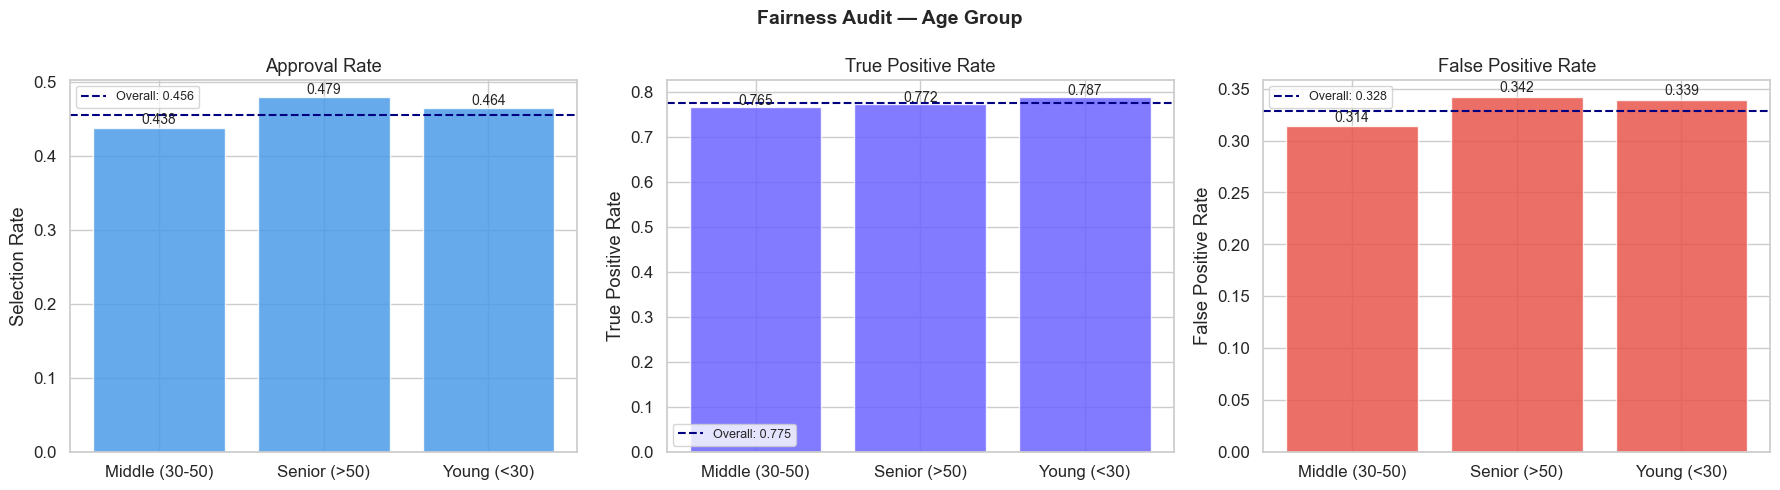

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fairness Audit — Age Group', fontsize=14, fontweight='bold')

for ax, metric, color, title in zip(axes,
    ['selection_rate','true_positive_rate','false_positive_rate'],
    ['#4C9BE8','#6C63FF','#E8554C'],
    ['Approval Rate','True Positive Rate','False Positive Rate']):

    vals = mf_age.by_group[metric]
    ovr  = mf_age.overall[metric]
    bars = ax.bar(vals.index, vals.values, color=color, edgecolor='white', alpha=0.85)
    ax.axhline(ovr, color='navy', linestyle='--', label=f'Overall: {ovr:.3f}')
    ax.set_title(title); ax.set_ylabel(metric.replace('_',' ').title())
    ax.legend(fontsize=9)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005,
                f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plots/06_fairness_age.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Fairness by Gender

In [5]:

SEX_IDX = feature_names.index('SEX')
genders = np.where(df_test['SEX'].values < 0, 'Male', 'Female')

mf_sex = MetricFrame(
    metrics={
        'accuracy':            lambda yt,yp: accuracy_score(yt,yp),
        'selection_rate':      selection_rate,
        'true_positive_rate':  true_positive_rate,
        'false_positive_rate': false_positive_rate,
    },
    y_true=y_test, y_pred=y_pred, sensitive_features=genders
)
dp_sex = demographic_parity_difference(y_test, y_pred, sensitive_features=genders)
eo_sex = equalized_odds_difference(y_test,    y_pred, sensitive_features=genders)

print("Metrics by Gender:")
print(mf_sex.by_group.round(4).to_string())
print(f"\nDemographic Parity Diff : {dp_sex:.4f}")
print(f"Equalized Odds Diff     : {eo_sex:.4f}")


Metrics by Gender:
                     accuracy  selection_rate  true_positive_rate  false_positive_rate
sensitive_feature_0                                                                   
Female                 0.7040          0.4328              0.7562               0.3150
Male                   0.6968          0.4908              0.7988               0.3498

Demographic Parity Diff : 0.0579
Equalized Odds Diff     : 0.0426


## 4. Fairness Summary Dashboard

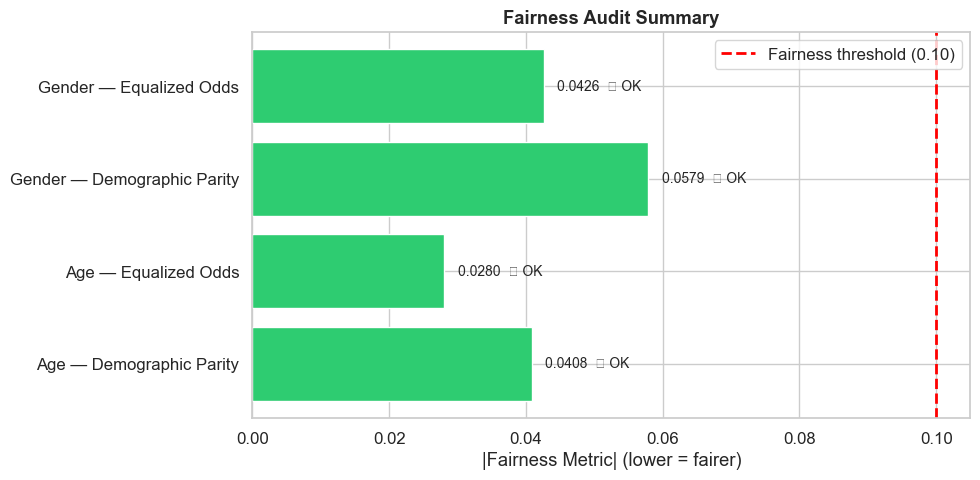


Fairness Report:
  Age — Demographic Parity                : 0.0408  ✅ OK
  Age — Equalized Odds                    : 0.0280  ✅ OK
  Gender — Demographic Parity             : 0.0579  ✅ OK
  Gender — Equalized Odds                 : 0.0426  ✅ OK


In [6]:

summary = {
    'Age — Demographic Parity':    abs(dp_age),
    'Age — Equalized Odds':         abs(eo_age),
    'Gender — Demographic Parity': abs(dp_sex),
    'Gender — Equalized Odds':      abs(eo_sex),
}

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#E8554C' if v > 0.1 else '#2ecc71' for v in summary.values()]
bars    = ax.barh(list(summary.keys()), list(summary.values()),
                  color=colors, edgecolor='white')
ax.axvline(0.1, color='red', linestyle='--', linewidth=2,
           label='Fairness threshold (0.10)')
ax.set_xlabel('|Fairness Metric| (lower = fairer)')
ax.set_title('Fairness Audit Summary', fontweight='bold')
ax.legend()
for bar, v in zip(bars, summary.values()):
    status = '⚠️ BIAS' if v > 0.1 else '✅ OK'
    ax.text(v+0.002, bar.get_y()+bar.get_height()/2,
            f'{v:.4f}  {status}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('plots/06_fairness_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFairness Report:")
for metric, val in summary.items():
    print(f"  {metric:40s}: {val:.4f}  "
          f"{'⚠️ BIAS' if val>0.1 else '✅ OK'}")
